<img src="../../images/arm_logo.png" width=500 alt="ARM Logo"></img>

# Unsupervised Learning for Characterizing Atmospheric Regimes from ARM Rawinsonde Data

:::{important} Goal
The goal of this notebook is to showcase an unsupervised learning technique utilizing ARM rawinsonde data. This workflow will performs best with GPU availability but can be run on a local CPU.

<a href="https://colab.research.google.com/github/ARM-Development/arm-summer-school-2026/blob/main/notebooks/ai-ml/unsupervised-learning-sonde.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Overview

For this tutorial, we will go over how to prepare ARM data for unsupervised learning workflows. We will do this by using a common example in the atmospheric sciences: leveraging clustering techniques to categorize atmospheric regimes from rawinsonde data. Such techniques have been used in the literature for two ARM central facilities: Tropical Western Pacific by @pope_regimes_2009 and North Slope of Alaska by @mulmenstadt_cloud_2012. This notebook goes over repeating such analysis for the Southern Great Plains site and includes:
1. Overview of Machine Learning Types
1. Practical Guidelines for Unsupervised Learning
1. Feature Extraction and Dimensionality Reduction
1. Data Standardization
1. K-means Clustering

## Prerequisites

For this tutorial, the reader will need to know how to read ARM data using ACT in the ACT Basics tutorial, linked to below [@theisen_act_2026]. We will introduce various techniques in scikit-learn as we go in this tutorial, so having an understanding of the basics of scikit-learn is helpful but not necessary for this tutorial.

| Concepts | Importance | Notes |
| --- | --- | --- |
| [ACT Basics](https://arm-development.github.io/arm-summer-school-2026/act-basics-bnf/) | Necessary | |
| [Understanding of NetCDF](https://foundations.projectpythia.org/core/data-formats/netcdf-cf.html) | Helpful | Familiarity with metadata structure |
| [Scikit-learn](https://scikit-learn.org/stable/) | Helpful | Machine learning library for clustering and preprocessing |


- **Time to learn**: 30 minutes
- **System requirements**:
---

## Overview of Machine Learning Types

Machine learning encompasses several fundamental approaches to training models:

### **Supervised Learning**
Models trained on labeled data where each input sample is paired with a known output (target). The model learns to map inputs to outputs.
- **Examples**: Classification (predicting categories), Regression (predicting continuous values)
- **Use cases**: Image classification, DQ flagging, retrievals

### **Unsupervised Learning**
Models trained on unlabeled data to discover hidden patterns, structures, or relationships without predefined targets.
- **Examples**: Clustering (grouping similar samples), Dimensionality reduction, Anomaly detection
- **Use cases**: Anomaly detection, regime classification, DQ flagging


### **Self-Supervised Learning**
A form of unsupervised learning where labels are automatically generated from the data itself, allowing models to learn useful representations without manual annotation.
- **Examples**: Contrastive learning, Masked language modeling, Rotation prediction
- **Use cases**: Pre-training large models, learning from unlabeled data at scale

### **Semi-Supervised Learning**
Combines a small amount of labeled data with a large amount of unlabeled data to improve model performance.
- **Use cases**: When labeling data is expensive, leveraging unlabeled data efficiently. 

### **Reinforcement Learning**
Models learn by interacting with an environment, receiving rewards or penalties for actions taken.
- **Examples**:  Decision-making systems
- **Use cases**: Autonomous systems, optimization problems

For the Summer School, we will be focusing on two of these: *Supervised Learning* and *Unsupervised Learning*. 

## Practical Guidelines for Unsupervised Learning

:::{important}**Rule of Thumb for Data Requirements:**
For unsupervised learning, a practical guideline is to have at least **100-1000 data points per feature/dimension**. 
:::

More specifically:
- Simple models (k-means, basic clustering): 100-300 points per feature
- Moderate complexity (hierarchical clustering, mixture models): 500-1000 points per feature  
- Complex models (deep autoencoders, advanced manifold learning): 1000+ points per feature
- Aim for at least **10x-100x more samples than the number of features** to avoid the "curse of dimensionality"

This ensures sufficient data density for discovering meaningful patterns without overfitting. For this afternoon's example, we will only be using a simple model. The below illustration shows the three different scenarios that can occur based on model complexity when fitting your model. 

- Underfitting occurs when the model is not complex enough to capture the observed trends.
- A robust fit occurs when the model complexity matches the dataset complexity
- Overfitting occurs when the dataset size is insufficient for the complexity of the model.

We also have to determine the complexity of our model by incorporating the **bias-variance tradeoff**: 

- A simpler model will exhibit less variance, but have a high bias. 
- Consequently, a complex model reduces bias at the cost of high variance. 

<img src="https://analystprep.com/study-notes/wp-content/uploads/2021/03/Img_13.jpg">

## Feature Extraction and Dimensionality Reduction

The next step in an unsupervised learning workflow is to determine which features you need for your workflow. This depends on your problem. In the problem of categorizing atmospheric regimes, we are typically interested in the vertical column of thermodynamic and kinematic parameters that show how temperature, relative humidity, and winds vary throughout the whole column.

However, each rawinsonde file contains thousands of features for each sample. This leads to the **curse of dimensionality**. Generally, having thousands of features, especially for simpler machine learning workflows such as clustering, will result in the model underfitting and unacceptable inference and training times—if training even succeeds. Therefore, we must perform **dimensionality reduction** on the data to make it amenable for AI/ML techniques.

There are two main approaches for dimensionality reduction:

### 1. Domain Expertise-Based Feature Selection
Use domain knowledge to extract relevant features. For example, we know that wind speed and direction at 499 hPa pressure will likely be correlated with those at 500 hPa. Therefore, not all features are independent and typically covary in your dataset. One can simply choose specific heights in the rawinsonde data to extract.

Both the @pope_regimes_2009 and @mulmenstadt_cloud_2012 studies employ this technique, with @pope_regimes_2009 choosing temperature (`T`), zonal wind (`U`), and meridional (`V`) wind speed at the following pressure levels:
- 1013 hPa (surface)
- 950, 925, 900, 850, 800, 750, 700, 650, 600, 550, 500, 400, 300, 200, and 100 hPa

This reduces the features to 48, which is much more amenable for AI/ML techniques.

### 2. Principal Component Analysis (PCA)
Automatically determine the covariance of features using **Principal Component Analysis (PCA)**. PCA computes the first *n* normal eigenvalues and eigenvectors of the covariance matrix containing all samples in your data. The eigenvectors are called the *principal components* of the input feature space. The eigenvalues show the amount of variance in the input features attributed to each principal component.

Therefore, one can see how much of the feature space variance is attributed to specific features and obtain orthogonal dimensions to project your feature space into. Using the first *x* principal components that explain 95% of the variance is another common technique for dimensionality reduction. This assumes that the number of dimensions can be reduced in this manner, which is not always possible.

:::{admonition}**If Running these Notebooks on Google CoLab**
You will need to include the Atmospheric data Community Toolkit (ACT) within the python environment.
Uncomment the next line prior to importing the python libraries.
:::

In [ ]:
# Uncomment if running on CoLab
##!pip install act-atmos>=2.2.23

In [1]:
import act 
import matplotlib.pyplot as plt
import xarray
import os
import xarray as xr 
import numpy as np
import glob

# Scikit-learn imports
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Dask imports
from distributed import Client, LocalCluster, progress

### Loading Rawinsonde data from ARM Data Discovery
First, we will download all of the data from ARM Data Discovery. For this example, we will use 10 years of SGP rawinsonde launch data (@keeler_sgp_sonde) for training: 2015-2025. The ARM Facility launches soundings four times a day at all of their central facilties and mobile facility deployments, providing a detailed record of the kinematic and thermodynamic profiles over the sites.

<img src="https://armgov.svcs.arm.gov/uploads/52345901419_6c4ca23fd7_k.jpg" width=400>


The `act.discovery.download_arm_data` module uses the `ARM_USERNAME` and `ARM_PASSWORD` environment variables as logins to the ARM Live API. 

For more information on the ARMLive API and registering for access, go to [ARM Live](https://adc.arm.gov/armlive/).

The rawinsonde data are stored in the `sgpsondewnpnC1.b1` datastream.

In [ ]:
act.discovery.download_arm_data(os.environ["ARM_USERNAME"], os.environ["ARM_PASSWORD"], 
                                'sgpsondewnpnC1.b1', '2017-11-01', '2018-01-01')

### Feature extraction -- domain expertise based

The `extract_features` function below implements domain expertise-based feature selection by sampling rawinsonde profiles at a fixed set of standard pressure levels. Rather than using every observation in a sounding (thousands of points at irregular pressure intervals), we select values at 15 of the 16 pressure levels from @pope_regimes_2009:

| Range | Levels (hPa) |
|-------|-------------|
| Lower troposphere | 950, 925, 900, 850, 800, 750 |
| Mid-troposphere | 700, 650, 600, 550, 500 |
| Upper troposphere | 400, 300, 200, 100 |

For each sounding file, the function:
1. **Sorts** the profile by pressure descending so that the surface observation is first and the tropopause is last
2. **Finds** the nearest observation to each target level using `np.argmin` on the absolute pressure differences — exact matches are rare because the balloon ascends continuously
3. **Extracts** dry bulb temperature (`tdry`), zonal wind (`u_wind`), and meridional wind (`v_wind`) at each matched level
4. **Concatenates** the three variables along a single `feature` dimension, yielding a 48-element vector (16 levels × 3 variables) per sounding

The resulting feature vector captures the thermodynamic and kinematic state of the full atmospheric column in a compact, fixed-length representation suitable for machine learning.

In [60]:
sonde_ds = act.io.read_arm_netcdf('./sgpsondewnpnC1.b1/sgpsondewnpnC1.b1.20171107.172800.cdf')

We want the `tdry`, `u_wind`, and `v_wind` variables at the 16 specified pressure levels for each rawinsonde. The function accepts either a file path (string) or a pre-loaded `xarray.Dataset`. When given a path it loads the file via ACT; any file that fails to load returns `None` and is filtered out later during concatenation.

The output is a 48-element `xarray.DataArray` with:
- **Dimension**: `feature` — integer-indexed 0–47 (unnamed, not tied to pressure)
- **Coordinate `pres`**: the *actual* pressure values from the sounding at the selected indices, which are close but not necessarily identical to the target levels
- **Coordinate `time`**: the timestamps at the selected indices within the balloon flight

The 48 features are ordered as: `tdry[0..15]`, `u_wind[0..15]`, `v_wind[0..15]`, where index 0 corresponds to 1013 hPa and index 15 to 100 hPa.

In [42]:
def extract_features(sonde_ds, 
                     levels=None):
    """Extract features from a sounding at specific pressure levels.

    Parameters
    ----------
    sonde_ds : xarray.Dataset or string
        Rawinsonde dataset loaded from ACT.
    levels : list of int or float, optional
        Pressure levels (hPa) to select. Default is the standard set used in Pope et al.:
        [975, 950, 925, 900, 850, 800, 750, 700, 650, 600, 550, 500, 400, 300, 200, 100].

    Returns
    -------
    xarray.DataArray
        Concatenated features (tdry, u_wind, v_wind) at the requested pressure levels.
    """

    if isinstance(sonde_ds, str):
        try:
             sonde_ds = act.io.read_arm_netcdf(sonde_ds)
        except Exception as e:
            return None
    if levels is None:
        levels = [975, 950, 925, 900, 850, 800, 750, 700, 650, 600, 550, 500, 400, 300, 200, 100]

    # Ensure pressure coordinate exists and is ordered for nearest-level lookup
    if 'pres' not in sonde_ds.coords:
        # In many ACT sonde files, pres may be a variable rather than coordinate
        if 'pres' in sonde_ds:
            sonde_ds = sonde_ds.set_coords('pres')
        else:
            raise KeyError("Dataset does not contain 'pres' variable/coordinate for pressure levels")

    sonde_ds = sonde_ds.sortby('pres', ascending=False)
    sonde_ds = sonde_ds.load()  # force evaluation before selection
    temp = []
    u_wind = []
    v_wind = []
    for level in levels:
        pres_index = np.argmin(np.abs(sonde_ds["pres"].values - level))
        temp.append(sonde_ds['tdry'].isel(time=pres_index))
        u_wind.append(sonde_ds['u_wind'].isel(time=pres_index))
        v_wind.append(sonde_ds['v_wind'].isel(time=pres_index))
    temp = xr.concat(temp, dim='feature')
    u_wind = xr.concat(u_wind, dim='feature')
    v_wind = xr.concat(v_wind, dim='feature')
    features = xr.concat([temp, u_wind, v_wind], dim='feature')
    
    return features
    #return temp, u_wind, v_wind

Let's test our feature extraction on a single sounding. The output should be a 48-element `DataArray`. A few things to verify in the result:
- The `pres` coordinate values should be close (but not identical) to the target levels `[975, 950, 925, ...]`
- There should be no unexpected `NaN` values in the interior of the profile; missing data near the surface or above the tropopause is common and acceptable
- Feature values should look physically reasonable — for example, temperatures near −20°C at 500 hPa for a midlatitude sounding, and wind components that are plausible in magnitude

In [44]:
features = extract_features(sonde_ds)
features

<xarray.DataArray 'tdry' (feature: 48)> Size: 192B
array([  4.06      ,   2.04      ,   0.1       ,   0.72      ,
         2.23      ,   4.06      ,   7.02      ,   3.57      ,
        -1.28      ,  -5.83      , -10.83      , -15.48      ,
       -24.78      , -39.07      , -56.22      , -69.67      ,
         0.31409642,  -0.9930204 ,  -3.320795  ,  -6.225285  ,
        -4.097656  ,   2.1631186 ,   8.138879  ,  11.671499  ,
        15.341398  ,  18.934832  ,  25.284822  ,  30.1734    ,
        41.690285  ,  55.366253  ,  61.06278   ,  30.59534   ,
        -8.994517  ,  -9.447958  ,  -9.644289  ,  -4.8637257 ,
        -3.2014396 ,  -6.657396  ,  -0.99932694,  -0.8161518 ,
         1.3421979 ,   5.788964  ,   4.0047235 ,   3.7048354 ,
         5.859194  ,  -1.9334219 ,  -2.1323478 ,   0.5340403 ],
      dtype=float32)
Coordinates:
    pres     (feature) float32 192B 974.7 949.9 924.7 ... 299.9 200.0 99.97
    time     (feature) datetime64[ns] 384B 2017-11-07T17:28:22 ... 2017-11-07...
Dimensions without coordinates: feature
Attributes:
    long_name:    Dry Bulb Temperature
    units:        C
    valid_min:    -90.0
    valid_max:    50.0
    valid_delta:  10.0
    resolution:   0.1

## Apply en masse to dataset

Now we will apply our feature extraction function to all rawinsonde files in the dataset. We use **Dask** to parallelize the work across multiple CPU cores:

- `LocalCluster(n_workers=4, threads_per_worker=1)` starts a local scheduler with 4 independent worker processes — each worker handles one sounding file at a time
- `client.submit(extract_features, file)` schedules the function call as a **non-blocking future**; control returns immediately without waiting for the result, so all files are queued rapidly
- `client.gather(features_list)` **blocks** until every submitted task completes, then returns all results in submission order
- Any sounding that failed to load (returned `None`) is filtered out with the list comprehension before concatenation
- `xr.concat(..., dim='sample')` stacks all 48-element feature vectors into a 2-D array of shape `(n_soundings, 48)`

This parallel approach reduces wall time roughly 4× compared to sequential processing for a dataset of this size.

In [17]:
sounding_data_files = sorted(glob.glob('sgpsondewnpnC1.b1/sgpsondewnpnC1.b1.*.cdf'))

with LocalCluster(n_workers=4, threads_per_worker=1) as cluster, Client(cluster) as client:
    print(f"Dask cluster dashboard available at: {client.dashboard_link}")
    features_list = []
    for file in sounding_data_files:
        features_list.append(client.submit(extract_features, file))
    features_list = client.gather(features_list)

dataset = xr.concat([x for x in features_list if x is not None], dim='sample')

Dask cluster dashboard available at: http://127.0.0.1:8787/status


Let's view the output dataset. The result should be a 2-D `DataArray` with dimensions `(sample, feature)`:

- **`sample`**: one row per valid sounding; any files that failed extraction were dropped
- **`feature`**: 48 columns — 16 pressure levels × 3 variables (`tdry`, `u_wind`, `v_wind`)

Note that the `pres` coordinate is 2-D `(sample, feature)` because the nearest-level pressure varies slightly from sounding to sounding depending on the balloon's exact ascent path. The `time` coordinate is similarly 2-D, recording the in-flight timestamp of each selected observation.

## Data Standardization

Most AI/ML techniques, particularly distance-based clustering algorithms like k-means, are sensitive to the scale of features. Without proper scaling, features with larger numerical ranges will dominate the distance calculations, potentially overshadowing more meaningful but smaller-scale features.

### Standardization vs. Normalization

#### **Standardization (Z-score normalization)**
Transforms data to have mean = 0 and standard deviation = 1:
$$X_{standardized} = \frac{X - \mu}{\sigma}$$

**When to use:**
- When features follow a **normal (Gaussian) distribution**
- For clustering algorithms like **k-means, hierarchical clustering, and Gaussian mixture models**
- When you want to preserve outliers but reduce their impact
- For algorithms that assume normally distributed data

**Advantages:**
- Interpretable results (values in units of standard deviations)
- Works well with unbounded features
- Better for algorithms sensitive to feature variance

#### **Normalization (Min-Max scaling)**
Scales features to a fixed range, typically [0, 1]:
$$X_{normalized} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

**When to use:**
- When features have **known bounds** or you need output in a specific range
- When distribution is **non-normal** (e.g., uniform, skewed)
- For neural network-based clustering (e.g., autoencoders)
- When outliers should not unduly influence the scaling

**Advantages:**
- Intuitive: all features bounded to [0, 1]
- Better for outlier-heavy datasets
- Good for algorithms with activation functions (sigmoid, etc.)

### For Atmospheric Data

In our rawinsonde clustering problem, we recommend **standardization** because:
1. Temperature, wind speed, and humidity often follow approximately normal distributions
2. k-means assumes isotropic variance and works better with standardized features
3. Vertical wind and zonal/meridional components have different units and ranges, so standardization levels the playing field
4. The physical relationships between features are preserved better with z-score normalization

In [47]:
# First, we remove any features with NaN values, as KMeans cannot handle them.
dataset = dataset.dropna(dim='sample', how='any')
scaler = StandardScaler()
scaled_features = scaler.fit_transform(dataset.values)

## Exploring the Feature Space with PCA

### What is Principal Component Analysis?

PCA is a linear dimensionality reduction technique that finds the directions of maximum variance in a dataset. Given a matrix of standardized samples $X$ (shape $n \times p$), PCA computes the **eigendecomposition of the covariance matrix**:

$$C = \frac{1}{n-1} X^T X$$

$$C \mathbf{v}_k = \lambda_k \mathbf{v}_k$$


Each eigenvector $\mathbf{v}_k$ is a **principal component** — a direction in the original 48-dimensional feature space. The associated eigenvalue $\lambda_k$ tells you how much variance is captured along that direction. PCA orders components so that $\lambda_1 \geq \lambda_2 \geq \cdots$, meaning PC1 always captures the most variance, PC2 the next most, and so on.

Projecting the data onto the first $k$ PCs gives the best possible $k$-dimensional approximation of the original data (in a least-squares sense). If 95% of the total variance is captured by, say, 10 components, the remaining 38 dimensions are mostly noise and can be discarded without much loss.

> **Why standardize first?** PCA is sensitive to scale. Without standardization, features with large numerical ranges (e.g., surface pressure in hPa) would dominate the covariance matrix over features with small ranges (e.g., upper-tropospheric winds in m/s), regardless of physical importance.

### What the plots show

- **Scree plot (left)**: bars show the variance fraction captured by each individual component; the red cumulative line shows the running total. The dashed line marks 95% — the vertical dotted line shows how many PCs are needed to reach it.
- **PC1 vs PC2 scatter (right)**: projects all soundings onto the two most informative directions. Visible clusters or gradients here are a sign that the data has separable regimes — a good omen for k-means clustering.

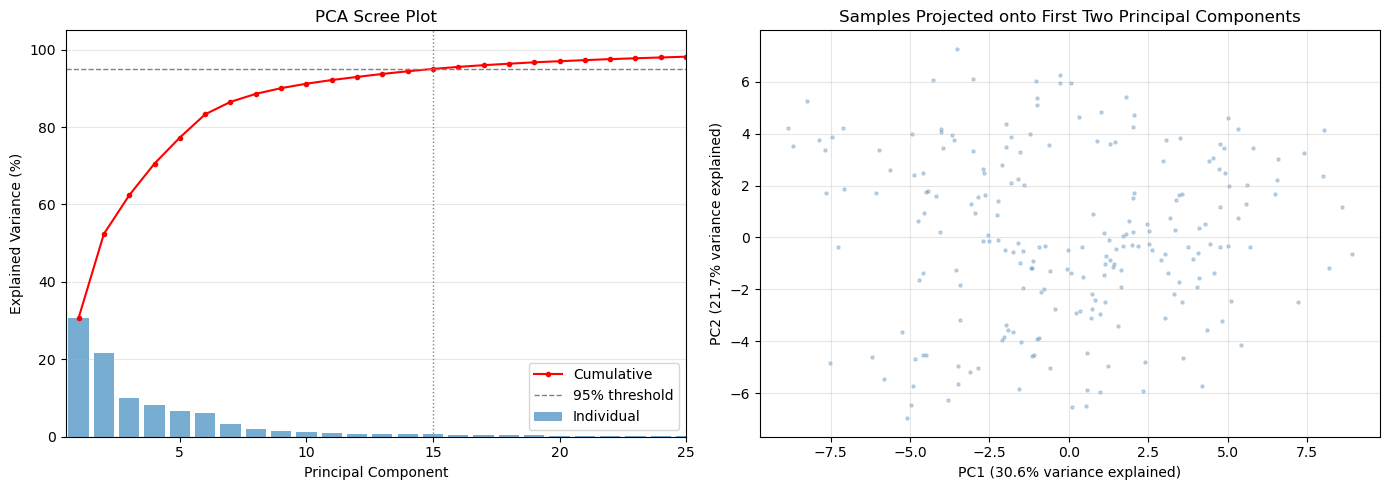

Components needed for 95% variance: 15
Components needed for 99% variance: 31


In [48]:
from sklearn.decomposition import PCA

# Fit PCA retaining all components so we can inspect the full variance spectrum
pca = PCA()
pca.fit(scaled_features)
pcs = pca.transform(scaled_features)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components = np.arange(1, len(pca.explained_variance_ratio_) + 1)
n_95 = int(np.searchsorted(cumulative_variance, 0.95)) + 1
n_99 = int(np.searchsorted(cumulative_variance, 0.99)) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: scree plot ---
axes[0].bar(n_components, pca.explained_variance_ratio_ * 100, alpha=0.6, label='Individual')
axes[0].plot(n_components, cumulative_variance * 100, marker='o', markersize=3,
             color='red', label='Cumulative')
axes[0].axhline(95, color='gray', linestyle='--', linewidth=1, label='95% threshold')
axes[0].axvline(n_95, color='gray', linestyle=':', linewidth=1)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('PCA Scree Plot')
axes[0].set_xlim(0.5, 25)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# --- Right: PC1 vs PC2 scatter ---
axes[1].scatter(pcs[:, 0], pcs[:, 1], alpha=0.3, s=5, color='steelblue')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance explained)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance explained)')
axes[1].set_title('Samples Projected onto First Two Principal Components')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Components needed for 95% variance: {n_95}")
print(f"Components needed for 99% variance: {n_99}")

## K-means Clustering

K-means is one of the most widely used unsupervised learning algorithms for clustering. It partitions data into *k* distinct clusters by minimizing the within-cluster variance.

### How K-means Works

1. **Initialization**: Randomly select *k* initial cluster centers (centroids) from the data
2. **Assignment**: Assign each data point to the nearest centroid using Euclidean distance
3. **Update**: Calculate the mean of each cluster and move centroids to these new means
4. **Convergence**: Repeat steps 2-3 until centroids stop moving or max iterations reached

### Key Characteristics

- **Unsupervised**: Does not require labeled training data
- **Distance-based**: Minimizes the sum of squared distances within clusters
- **Deterministic clusters**: Hard assignment (each point belongs to exactly one cluster)
- **Scalable**: Works well with large datasets
- **Scale-sensitive**: Requires standardized/normalized data (why we used StandardScaler)

### Choosing the Number of Clusters (*k*)

Determining the optimal number of clusters is critical and can be done using:

- **Elbow method**: Plot inertia (sum of squared distances) vs. *k* and look for the "elbow" where adding more clusters doesn't significantly reduce inertia
- **Silhouette score**: Measures how similar points are to their own cluster compared to other clusters (higher is better, range: [-1, 1])
- **Domain knowledge**: Use your understanding of atmospheric regimes (e.g., from Pope et al., typical values are 3-5 regimes)

### For Atmospheric Regimes

In clustering rawinsonde data:
- *k* typically ranges from **3-5 regimes** based on meteorological understanding
- The elbow method often reveals a natural break point around 3-4 clusters
- Each cluster represents a physically coherent atmospheric regime (e.g., moist, dry, transitional)

### Choosing k with the Elbow Method

Before running k-means, we need to decide how many clusters (*k*) to use. The **elbow method** gives an empirical guide.

**Inertia** (also called within-cluster sum of squares, WCSS) measures how compact the clusters are — it is the total squared Euclidean distance from each point to its assigned cluster centroid:

$$\text{Inertia} = \sum_{i=1}^{N} \| x_i - \mu_{c(i)} \|^2$$

As *k* increases, inertia always decreases because each cluster shrinks. The rate of decrease slows once we have enough clusters to capture the main structure in the data. The "elbow" — the kink in the curve where improvement becomes marginal — indicates a good trade-off between cluster compactness and model complexity.

The code below fits k-means for *k* = 2 through 9, stores each trained model (so we can reuse them without refitting), and plots inertia vs. *k*. Look for the value of *k* where the curve transitions from a steep to a shallow slope.

In [49]:
kmeans_models = []
for n_clusters in range(2, 20):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(scaled_features)
    kmeans_models.append(kmeans)


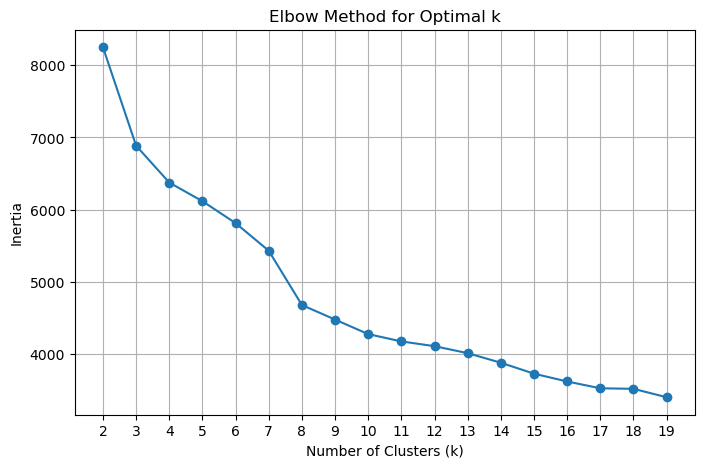

In [50]:
n_clusters = range(2, 20)
inertia = [model.inertia_ for model in kmeans_models]
plt.figure(figsize=(8, 5))
plt.plot(n_clusters, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(n_clusters)
plt.grid()
plt.show()

### Choosing k with the Silhouette Score

The elbow method is a useful heuristic, but it can be ambiguous when the curve bends gradually. The **silhouette score** provides a complementary, more interpretable metric.

For each point $x_i$, the silhouette coefficient is:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\ b(i))}$$

where:
- $a(i)$ = mean distance from $x_i$ to all other points **in the same cluster** (cohesion)
- $b(i)$ = mean distance from $x_i$ to all points in the **nearest neighboring cluster** (separation)

The overall silhouette score is the mean of $s(i)$ across all points, and ranges from **−1 to 1**:
- **Close to 1**: points are well-matched to their own cluster and clearly separated from others
- **Close to 0**: points are near a cluster boundary
- **Negative**: points may have been assigned to the wrong cluster

Unlike inertia, the silhouette score is **not monotone** with *k* — it peaks at the number of clusters that best separates the data. The optimal *k* is the one with the highest silhouette score.

> **Note** Computing the exact silhouette score over thousands of samples is $O(n^2)$ and slow. We use `sample_size=2000` to estimate it from a random subset, which is accurate enough for cluster selection.

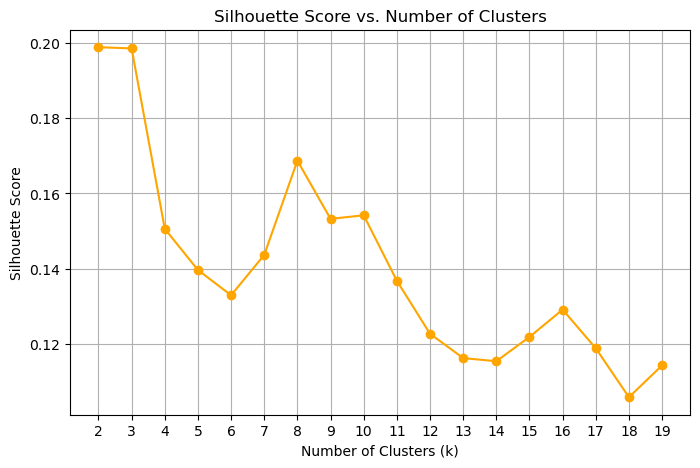

In [51]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for model in kmeans_models:
    score = silhouette_score(scaled_features, model.labels_, sample_size=2000, random_state=42)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(list(n_clusters), silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(list(n_clusters))
plt.grid()
plt.show()

There are two "peaks" here, one at 2 and one at 8, where the approximate location of the elbow is. Overall, the silhouette scores are low, showing a significant amount of overlap between the clusters. This also shows us that the feature space is likely inadequate for separating all of the clusters. 

**An exercise for the student: see what the effect of the feature space is on this analysis**.

### Mapping clusters back to raw sounding files

The feature dataset holds one row per sounding with the 48 extracted features, but we need to re-open the **original full-resolution sounding files** to plot complete vertical profiles. The challenge is that the `time` coordinates in the feature dataset record in-flight timestamps (one per pressure level), not the launch time — so we cannot directly join on time.

The mapping strategy below works around this:
1. **Parse** the launch timestamp from each sounding filename using a regex on the `YYYYMMDD.HHMMSS` portion of the filename
2. **Extract** one representative time per sample from the feature dataset's `time` coordinate (a slice through the 2-D time array)
3. **Match** each sample to the sounding file whose parsed launch time is nearest in seconds (nearest-neighbor lookup)
4. **Store** the matched file path in `nearest_file` so any subsequent cell can re-open the full-resolution raw data for a given sample index

After this mapping, `nearest_file[i]` is the path to the source sounding for sample `i` in the feature dataset.

In [52]:
import pandas as pd
import re

# Parse timestamps from the rawinsonde file names

def parse_sounding_timestamp(filename):
    base = os.path.basename(filename)
    match = re.search(r"(\d{8})[._-](\d{6})", base)
    if match is None:
        raise ValueError(f"Cannot parse timestamp from file name: {base}")
    return pd.to_datetime(match.group(1) + match.group(2), format="%Y%m%d%H%M%S")

sounding_times = pd.Series(
    [parse_sounding_timestamp(f) for f in sounding_data_files],
    index=sounding_data_files,
)

# Extract sample times from the feature dataset
if 'time' not in dataset.coords:
    raise KeyError("Expected a 'time' coordinate on the feature dataset for each sample")

sample_times = pd.to_datetime(np.asarray(dataset['time'].values)).ravel()

nearest_file = []
nearest_file_time = []
sounding_timestamps = [x.timestamp() for x in sounding_times]
for sample_time in sample_times:
    deltas = np.abs(np.array(sounding_timestamps) - sample_time[0].timestamp())
    closest_idx = deltas.argmin()
    nearest_file.append(sounding_times.index[closest_idx])
    nearest_file_time.append(sounding_times.iloc[closest_idx])


### Selecting the final model

Based on the silhouette score plot above, we select the model with the highest silhouette score peak as our final clustering. Here we pull the already-fitted `KMeans` object for that *k* from `kmeans_models` — no refitting needed since all models were trained in the elbow-method loop.

In [53]:
num_clusters = 7

for model in kmeans_models:
    if model.n_clusters == num_clusters:
        selected_model = model

## Computing and plotting cluster mean profiles

Now that each sounding has a cluster label, we want to compute a **mean vertical profile** for each cluster and display it as a Skew-T diagram. Two functions handle this:

### `make_cluster_profiles`

This function iterates over every cluster and every sounding assigned to it. For each sounding it:

1. **Opens** the original full-resolution file (using the `nearest_file` mapping from the previous cell)
2. **Sorts** by pressure descending and swaps the dimension so pressure is the primary coordinate (rather than time)
3. **Drops duplicate pressure levels** with `drop_duplicates('pres')` — duplicate values at the same pressure can occur when the balloon briefly stalls or descends, and they would break the monotonicity requirement for interpolation
4. **Interpolates** all four variables (`u_wind`, `v_wind`, `tdry`, `dp`) onto a common 1 hPa pressure grid from 975 to 100 hPa using linear interpolation
5. **Skips** any sounding that has `NaN` at any interpolated level — a sounding that didn't reach a given altitude cannot contribute a valid mean at that level
6. **Averages** the valid profiles using `np.nanmean` across all soundings in the cluster

The output is an `xarray.Dataset` with dimensions `(cluster, pres)` and unit attributes, ready for ACT's plotting tools.

### `plot_cluster`

A thin wrapper around ACT's `SkewTDisplay` that selects one cluster from the dataset by index and renders it as a Skew-T log-P diagram with wind barbs.

In [54]:
def make_cluster_profiles(pres_coords=np.arange(975, 100, -1)):
    v_wind_means = []
    u_wind_means = []
    t_means = []
    v_means = []
    td_means = []

    pres_coords = np.arange(975, 100, -1)
    for i in range(num_clusters):
        u_winds = []
        v_winds = []
        ts = []
        tds = []
        cluster_indices = np.where(selected_model.labels_ == i)[0]
        for idx in cluster_indices:
            with xr.open_dataset(nearest_file[idx]) as ds:
                ds = ds.sortby('pres', ascending=False).load()
                ds = ds.set_coords('pres').swap_dims({'time': 'pres'})  # Make pres the primary dimension
                ds = ds.drop_duplicates('pres')
                u_wind = ds['u_wind'].interp(pres=pres_coords, method='linear')
                if u_wind.isnull().any():
                    continue
                v_wind = ds['v_wind'].interp(pres=pres_coords, method='linear')
                if v_wind.isnull().any():
                    continue
                t = ds['tdry'].interp(pres=pres_coords, method='linear')
                if t.isnull().any():
                    continue
                td = ds['dp'].interp(pres=pres_coords, method='linear')
                if td.isnull().any():
                    continue
                u_winds.append(u_wind.values)
                v_winds.append(v_wind.values)
                ts.append(t.values)
                tds.append(td.values)
        if len(u_winds) == 0:
            print(f"Warning: Cluster {i} has no valid soundings after interpolation. Filling with NaNs.")
            u_wind_means.append(np.full_like(pres_coords, np.nan))
            v_wind_means.append(np.full_like(pres_coords, np.nan))
            t_means.append(np.full_like(pres_coords, np.nan))
            td_means.append(np.full_like(pres_coords, np.nan))
            continue
        u_winds = np.array(u_winds)
        v_winds = np.array(v_winds)
        ts = np.array(ts)
        tds = np.array(tds)
    
        u_wind_means.append(np.nanmean(u_winds, axis=0))
        v_wind_means.append(np.nanmean(v_winds, axis=0))
        t_means.append(np.nanmean(ts, axis=0))
        td_means.append(np.nanmean(tds, axis=0))
    u_wind_means = np.array(u_wind_means)
    v_wind_means = np.array(v_wind_means)
    t_means = np.array(t_means)
    td_means = np.array(td_means)

    # Put this into an xarray Dataset for easier plotting with ACT
    ds = xr.Dataset(
        {
            'u_wind': (('cluster', 'pres'), u_wind_means),
            'v_wind': (('cluster', 'pres'), v_wind_means),
            'tdry': (('cluster', 'pres'), t_means),
            'dp': (('cluster', 'pres'), td_means),
        },
        coords={
            'cluster': np.arange(num_clusters),
            'pres': pres_coords,
        }
    )
    ds['u_wind'].attrs['units'] = 'm/s'
    ds['v_wind'].attrs['units'] = 'm/s'
    ds['tdry'].attrs['units'] = 'degC'
    ds['dp'].attrs['units'] = 'degC'
    ds['pres'].attrs['units'] = 'hPa'
    return ds

def plot_cluster(ds, cluster_no, **kwargs):
    figsize = kwargs.get('figsize', (6, 8))
    fig = plt.figure(figsize=figsize)
    skewt = act.plotting.SkewTDisplay(ds.sel(cluster=cluster_no), set_fig=fig, 
                                      subplot_shape=(1,), **kwargs)
    skewt.plot_from_u_and_v('u_wind', 'v_wind', 'pres','tdry', 'dp',
                            set_title=f'Cluster {cluster_no} Mean Sounding')
    skewt.axes[0].set_ylim(1000, 100)
    return skewt.fig, skewt.axes

Now we call `make_cluster_profiles()` to aggregate profiles across all clusters. This opens every source sounding file in the dataset, so it will take a moment to run. The result is a compact `xarray.Dataset` with dimensions `(cluster, pres)` holding the mean temperature, dew point, and wind profiles for each regime.

In [55]:
ds = make_cluster_profiles()

### Visualizing a cluster mean sounding

`plot_cluster` renders the mean profile for a single cluster as a **Skew-T log-P diagram** using ACT's `SkewTDisplay`. A Skew-T is the standard meteorological way to visualize a vertical atmospheric sounding:

- **Temperature** (`tdry`, red) and **dew point** (`dp`, green) are plotted against log-pressure on the vertical axis. Temperature isotherms are skewed 45° to the right so that the two curves don't overlap at low levels.
- **Wind barbs** (from `u_wind` and `v_wind`) on the right side show wind speed and direction at each pressure level.
- The gap between the temperature and dew-point curves indicates how dry the layer is — a large gap means unsaturated air.

Each cluster's mean sounding summarizes the typical thermodynamic and kinematic state of all soundings assigned to that regime. Comparing Skew-T diagrams across clusters is an intuitive way to characterize what makes each regime physically distinct (e.g., warm and moist boundary layer vs. cold and dry, or strong westerly jet vs. weak winds).

Change `cluster_no` to view the mean sounding for any of the `num_clusters` regimes.

/Users/jrobrien/.vscode-micromamba/envs/arm-summer-school-2026-dev/lib/python3.11/site-packages/act/plotting/plot.py:81: UserWarning: Could not discern datastreamname and dict or tuple were not provided. Using defaultname of act_datastream!
  warnings.warn(


(<Figure size 600x800 with 1 Axes>,
 array([<SkewXAxes: title={'center': 'Cluster 5 Mean Sounding'}, xlabel='degree_Celsius', ylabel='hectopascal'>],
       dtype=object))

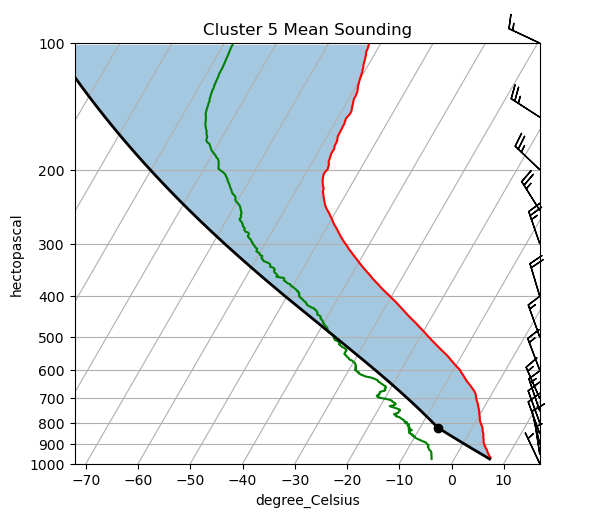

In [56]:
plot_cluster(ds, cluster_no=5)

### Comparing all cluster profiles side by side

The Skew-T view is detailed but shows one cluster at a time. The 2×2 panel below overlays the mean profiles for all clusters on shared axes, making it easier to spot what separates the regimes:

- **U wind (zonal)**: positive = westerly; negative = easterly
- **V wind (meridional)**: positive = southerly; negative = northerly
- **Temperature (T)**: governs atmospheric stability and lapse rate across the column
- **Dew point (Td)**: tracks moisture availability; a large T − Td spread indicates dry air far from saturation

Look for the **altitude range where clusters diverge most** — the level of maximum separation often points to the physical mechanism distinguishing the regimes (e.g., low-level jet signature at 850 hPa, a mid-tropospheric temperature inversion, or a moist boundary layer vs. a dry one).

/var/folders/7q/czgy7g_j3fb7jw3256f37wrw0000gq/T/ipykernel_79477/1570987615.py:11: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n = int(ds.dims['cluster'])
/Users/jrobrien/.vscode-micromamba/envs/arm-summer-school-2026-dev/lib/python3.11/site-packages/act/plotting/plot.py:81: UserWarning: Could not discern datastreamname and dict or tuple were not provided. Using defaultname of act_datastream!
  warnings.warn(


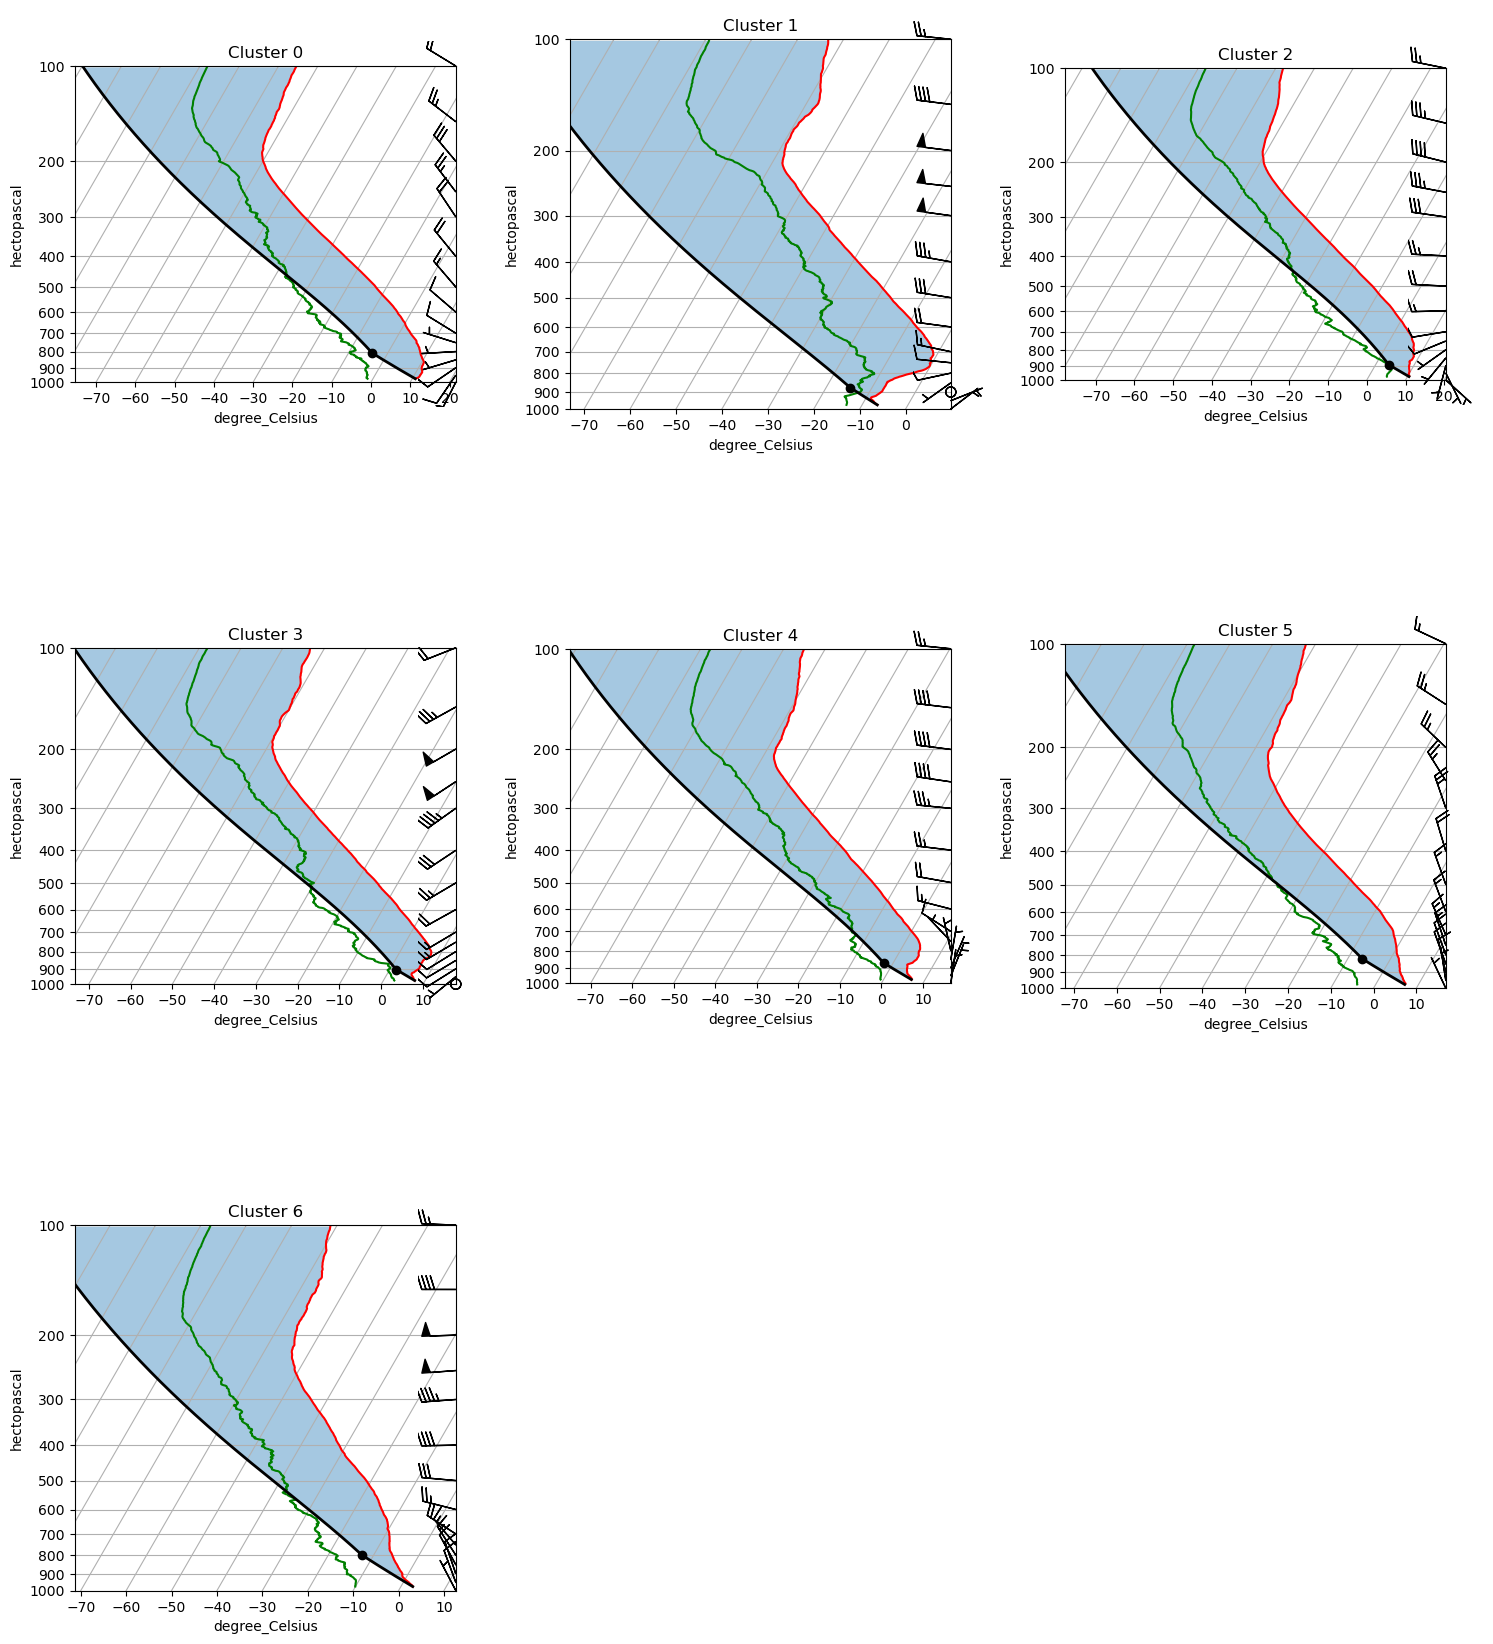

In [57]:
def plot_all_clusters(ds, ncols=3):
    """Plot a Skew-T log-P diagram for every cluster in a single figure.

    Parameters
    ----------
    ds : xarray.Dataset
        Dataset with dimensions (cluster, pres) as returned by make_cluster_profiles.
    ncols : int
        Number of columns in the subplot grid. Rows are computed automatically.
    """
    n = int(ds.dims['cluster'])
    ncols = min(n, ncols)
    nrows = (n + ncols) // ncols

    fig = plt.figure(figsize=(5 * ncols, 6 * nrows))

    # Initialise with the first cluster to build the full axes grid
    skewt = act.plotting.SkewTDisplay(
        ds.isel(cluster=0),
        set_fig=fig,
        subplot_shape=(nrows, ncols),
    )

    for i in range(n):
        row, col = divmod(i, ncols)
        # ACT stores the dataset in _ds under the key 'act_datastream'
        skewt._ds['act_datastream'] = ds.isel(cluster=i)
        skewt.plot_from_u_and_v(
            'u_wind', 'v_wind', 'pres', 'tdry', 'dp',
            set_title=f'Cluster {i}',
            subplot_index=(row, col),
        )
        skewt.axes[row, col].set_ylim(1000, 100)

    # Hide any unfilled panels in the last row
    for i in range(n, nrows * ncols):
        row, col = divmod(i, ncols)
        skewt.axes[row, col].set_visible(False)

    plt.tight_layout()
    return fig, skewt.axes

fig, axes = plot_all_clusters(ds)
plt.show()

### Interpreting the clusters

The mean profiles reveal distinct atmospheric regimes over the SGP site. Use the Skew-T diagrams and the side-by-side profile plots above to interpret each cluster.

| Cluster | Low-level winds | Upper-level winds | Temperature | Moisture | Likely regime |
|---------|----------------|-------------------|-------------|----------|---------------|
| 0 | Strong southwesterly | Weak Westerly | Warm | Moist (small T−Td) | Pre-frontal warm sector / LLJ |
| 1 | Calm | Strong westerly jet | Cold | Dry (large T−Td) | Post-frontal CAA |
| 2 | Westerly to southwesterly| Strong westerl y| Cool | Moist (small T−Td)| Pre-frontal warm sector | |
| 3 | Northeasterly | Strong westerly | Cold | Moist | Post-frontal |
| 4 | Strong southerly | Weak northweesterly | Warm | Moist | High pressure to east |
| 5 | Veering | West-northwesterly | Warm | Moist | Pre-frontal (rotational shear) |
| 6 | DQ Suspect | | | | |
---

**Cluster 0 — Warm, moist southwesterly flow (pre-frontal / warm sector)**
Strong southwesterly winds throughout the troposphere, warm temperatures, and relatively high dew points in the boundary layer. Characteristic of warm-sector conditions ahead of an approaching mid-latitude cyclone, when the Great Plains low-level jet transports Gulf of Mexico moisture northward into the SGP.

**Cluster 1 — Cold, dry post-frontal northwesterly flow**
Northeasterly to northwesterly winds near the surface transitioning to a strong upper-level westerly jet. Temperatures are colder throughout the column and the T − Td spread is larger (drier air) than Cluster 0. Consistent with continental polar air advection behind a cold front.

**Cluster 2 — Pre-frontal warm sector**
Westerly to southwesterly near the surface transitioning to a strong westerly jet aloft. It is cool and moist at the surface with CAPE. This is likely a pre-frontal regime. The directional shear implies that isolated supercells are less likely with this regime.

**Cluster 3 — Post-frontal cold sector**
Northeasterly to northwesterly winds near the surface transitioning to a strong upper-level westerly jet. Temperatures are colder throughout the column and the T − Td spread is small compared to cluster 1. Consistent with continental polar air advection behind a cold front. There is no CAPE, suggesting an environment favorable for large scale subsidence.

**Cluster 4 — High pressure to east**
This is a regime characterizes by warm temperatures and strong southerly winds with weak winds aloft. This is suggestive of a high pressure system to the east, bringing Gulf moisture in to the area. Short-lived convection is possible.

**Cluster 5 — Pre-frontal (rotational shear)**
This bears some similarity to cluster 2, except with a veering wind profile and greater CAPE. This regime is most favorable for severe weather over the SGP.

**Cluster 6 - Not enough valid data**
There were not enough valid observations to observe the mean profiles in this cluster. This is actually in itself useful for data quality flagging. At ARM, we are currently exploring how we can use machine learning to characterize data quality issues. Therefore, I would interpret the data from this cluster as suspect.


---

## Resources and references

### Further reading

- [Scikit-learn: Clustering user guide](https://scikit-learn.org/stable/modules/clustering.html) — comprehensive reference for all clustering algorithms below
- [ARM Data Discovery](https://adc.arm.gov/discovery/) — access ARM rawinsonde and other datasets
- [ACT documentation](https://arm-doe.github.io/ACT/) — ARM Community Toolkit for reading and plotting ARM data

### Alternative unsupervised learning algorithms

K-means is a natural starting point, but several other algorithms are worth exploring for atmospheric regime classification:

| Algorithm | Scikit-learn class | Key advantage for this problem |
|---|---|---|
| **Gaussian Mixture Models** | [`GaussianMixture`](https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html) | Soft (probabilistic) cluster assignments; handles ellipsoidal clusters; better uncertainty quantification |
| **Agglomerative / Hierarchical Clustering** | [`AgglomerativeClustering`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html) | No need to specify *k* in advance; dendrogram reveals natural hierarchy of regimes |
| **DBSCAN** | [`DBSCAN`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html) | Discovers arbitrarily shaped clusters; labels noise points explicitly; no *k* required |
| **HDBSCAN** | [`HDBSCAN`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.HDBSCAN.html) | Hierarchical extension of DBSCAN; more robust to varying density; better for high-dimensional data |
| **Self-Organizing Maps (SOM)** | [`MiniSom`](https://github.com/JustGlowing/minisom) (third-party) | Widely used in atmospheric science for regime classification; preserves topological structure |
| **Spectral Clustering** | [`SpectralClustering`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.SpectralClustering.html) | Graph-based; captures non-convex cluster shapes that k-means misses |
| **Autoencoder + Clustering** | PyTorch / TensorFlow | Learns a compressed latent representation of soundings before clustering; powerful for high-dimensional or non-linear structure |
---

:::{important}**Exercise for the Students**
Replace the k-means step with one of the algorithms above and compare the resulting regimes. 
Do the clusters change? Does the silhouette score improve?
:::